In [ ]:
!pip install torch pandas numpy tqdm

In [ ]:
!wget https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip
!unzip -o hetrec2011-lastfm-2k.zip

--2026-04-27 07:50:30--  https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2589075 (2.5M) [application/zip]
Saving to: ‘hetrec2011-lastfm-2k.zip’

hetrec2011-lastfm-2 100%[===================>]   2.47M  13.4MB/s    in 0.2s    

2026-04-27 07:50:30 (13.4 MB/s) - ‘hetrec2011-lastfm-2k.zip’ saved [2589075/2589075]

Archive:  hetrec2011-lastfm-2k.zip
  inflating: user_friends.dat        
  inflating: user_taggedartists.dat  
  inflating: user_taggedartists-timestamps.dat  
  inflating: artists.dat             
  inflating: readme.txt              
  inflating: tags.dat                
  inflating: user_artists.dat        


In [ ]:
import pandas as pd
import numpy as np

SAMPLE_SIZE = 150_000
ITEM_ITEM_TOPK = 100_000

# --- user_items ---
ua = pd.read_csv("user_artists.dat", sep="\t", encoding="latin-1")
user_items = ua.rename(columns={
    "userID": "user_id",
    "artistID": "item_id",
    "weight": "weight"
})

if len(user_items) > SAMPLE_SIZE:
    user_items = user_items.sample(SAMPLE_SIZE, random_state=42)

user_items["timestamp"] = np.arange(len(user_items))
user_items.to_csv("user_items.csv", index=False)

# --- item_tags ---
uat = pd.read_csv("user_taggedartists.dat", sep="\t", encoding="latin-1")
item_tags = uat.rename(columns={
    "artistID": "item_id",
    "tagID": "tag_id"
})[["item_id", "tag_id"]].drop_duplicates()

if len(item_tags) > SAMPLE_SIZE:
    item_tags = item_tags.sample(SAMPLE_SIZE, random_state=42)

item_tags.to_csv("item_tags.csv", index=False)

# --- item_item (co-occurrence) ---
pairs = {}
grouped = user_items.groupby("user_id")["item_id"].apply(lambda x: list(set(x)))

for items in grouped:
    L = len(items)
    for i in range(L):
        for j in range(i+1, L):
            a, b = items[i], items[j]
            pairs[(a, b)] = pairs.get((a, b), 0) + 1

item_item = pd.DataFrame(
    [(a, b, w) for (a, b), w in pairs.items()],
    columns=["item_id", "neighbor_item_id", "weight"]
)

item_item = item_item.sort_values("weight", ascending=False).head(ITEM_ITEM_TOPK)
item_item.to_csv("item_item.csv", index=False)

artist_genres = item_tags.copy()
artist_genres.columns = ["artist_id", "genre_id"]
artist_genres.to_csv("artist_genres.csv", index=False)

print("Done preprocessing")

Done preprocessing


In [ ]:
print(pd.read_csv("user_items.csv").shape)
print(pd.read_csv("item_tags.csv").shape)
print(pd.read_csv("item_item.csv").shape)
print(pd.read_csv("artist_genres.csv").shape)

(92834, 4)
(109750, 2)
(100000, 3)
(109750, 2)


In [ ]:
import torch
import random

def encode(series):
    vals = series.astype(str).drop_duplicates().tolist()
    return {v: i for i, v in enumerate(vals)}

def add_bi(edges, a, b, r):
    edges.append((a, b, r))
    edges.append((b, a, r))

def build_graph(ui_path, it_path, ii_path, ag_path):
    import pandas as pd

    ui = pd.read_csv(ui_path)
    it = pd.read_csv(it_path)
    ii = pd.read_csv(ii_path)
    ag = pd.read_csv(ag_path)

    for df in (ui, it, ii, ag):
        for c in df.columns:
            df[c] = df[c].astype(str)

    users = encode(ui["user_id"])
    items = encode(pd.concat([
        ui["item_id"], it["item_id"],
        ii["item_id"], ii["neighbor_item_id"],
        ag["artist_id"]
    ]))
    tags = encode(it["tag_id"])
    genres = encode(ag["genre_id"])

    offsets = {
        "user": 0,
        "item": len(users),
        "tag": len(users) + len(items),
        "genre": len(users) + len(items) + len(tags),
    }

    rel2id = {
        "user_item": 0,
        "item_tag": 1,
        "item_item": 2,
        "artist_genre": 3,
    }

    edges = []
    interactions = {}

    # user-item
    for r in ui.itertuples(index=False):
        u = users[r.user_id]; i = items[r.item_id]
        interactions.setdefault(u, set()).add(i)
        add_bi(edges, offsets["user"] + u, offsets["item"] + i, rel2id["user_item"])

    # item-tag
    for r in it.itertuples(index=False):
        add_bi(edges, offsets["item"] + items[r.item_id],
               offsets["tag"] + tags[r.tag_id], rel2id["item_tag"])

    # item-item
    for r in ii.itertuples(index=False):
        if r.item_id != r.neighbor_item_id:
            add_bi(edges, offsets["item"] + items[r.item_id],
                   offsets["item"] + items[r.neighbor_item_id],
                   rel2id["item_item"])

    # artist-genre
    for r in ag.itertuples(index=False):
        add_bi(edges, offsets["item"] + items[r.artist_id],
               offsets["genre"] + genres[r.genre_id],
               rel2id["artist_genre"])

    edge_index = torch.tensor([[e[0] for e in edges],
                               [e[1] for e in edges]], dtype=torch.long)
    edge_type = torch.tensor([e[2] for e in edges], dtype=torch.long)

    # split 80/20
    user_train, user_test = {}, {}
    for u, items_u in interactions.items():
        xs = list(items_u)
        random.shuffle(xs)
        sp = max(1, int(0.8 * len(xs)))
        user_train[u] = set(xs[:sp])
        user_test[u]  = set(xs[sp:]) if len(xs[sp:]) > 0 else set(xs[-1:])

    return {
        "num_users": len(users),
        "num_items": len(items),
        "num_nodes": len(users) + len(items) + len(tags) + len(genres),
        "edge_index": edge_index,
        "edge_type": edge_type,
        "user_train": user_train,
        "user_test": user_test,
        "offsets": offsets,
        "rel2id": rel2id,
    }

graph = build_graph(
    "user_items.csv", "item_tags.csv",
    "item_item.csv", "artist_genres.csv"
)

print(graph["num_users"], graph["num_items"], graph["num_nodes"])
print(graph["edge_index"].shape)

1892 18022 39412
torch.Size([2, 824668])


In [ ]:
import torch.nn as nn

class MultiRelLightGCN_Att(nn.Module):
    def __init__(self, num_nodes, num_relations, edge_index, edge_type,
                 emb_dim=128, num_layers=2):
        super().__init__()

        self.emb = nn.Embedding(num_nodes, emb_dim)
        nn.init.xavier_uniform_(self.emb.weight)

        self.rel_emb = nn.Embedding(num_relations, emb_dim)
        nn.init.xavier_uniform_(self.rel_emb.weight)

        self.rel_logit = nn.Parameter(torch.zeros(num_relations))

        self.edge_index = edge_index
        self.edge_type = edge_type
        self.num_relations = num_relations
        self.num_layers = num_layers

        src, dst = edge_index
        deg = torch.bincount(dst, minlength=num_nodes).float()
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0
        self.norm = deg_inv_sqrt[src] * deg_inv_sqrt[dst]

    def edge_gate(self, x_src, x_dst, rel_ids):
        r = self.rel_emb(rel_ids)
        score = (x_src * r).sum(-1) + (x_dst * r).sum(-1)
        return torch.sigmoid(score).unsqueeze(-1)

    def propagate(self, x):
        src, dst = self.edge_index
        out = torch.zeros_like(x)
        rel_alpha = torch.softmax(self.rel_logit, dim=0)

        for r in range(self.num_relations):
            mask = self.edge_type == r
            if mask.sum() == 0:
                continue

            s = src[mask]; d = dst[mask]
            msg = x[s]

            # attention
            gate = self.edge_gate(x[s], x[d], self.edge_type[mask])
            msg = msg * gate

            msg = msg * self.norm[mask].unsqueeze(-1) * rel_alpha[r]
            out.index_add_(0, d, msg)

        return out

    def forward(self):
        x = self.emb.weight
        layers = [x]
        for _ in range(self.num_layers):
            x = self.propagate(x)
            layers.append(x)
        return torch.stack(layers, dim=0).mean(dim=0), torch.softmax(self.rel_logit, dim=0)

In [ ]:
import math, random
import torch

def bpr_loss(user_emb, pos_emb, neg_emb, reg=1e-4):
    pos = (user_emb * pos_emb).sum(-1)
    neg = (user_emb * neg_emb).sum(-1)
    loss = -torch.log(torch.sigmoid(pos - neg) + 1e-8).mean()
    reg_term = reg * (
        user_emb.norm(2).pow(2) +
        pos_emb.norm(2).pow(2) +
        neg_emb.norm(2).pow(2)
    ) / user_emb.size(0)
    return loss + reg_term

def sample_batch(graph, batch_size=4096):
    users, pos, neg = [], [], []
    all_items = set(range(graph["num_items"]))
    active = [u for u, it in graph["user_train"].items() if it]

    for _ in range(batch_size):
        u = random.choice(active)
        i = random.choice(list(graph["user_train"][u]))
        forbidden = graph["user_train"][u] | graph["user_test"][u]
        candidates = list(all_items - forbidden)
        if not candidates:
            continue
        j = random.choice(candidates)

        users.append(graph["offsets"]["user"] + u)
        pos.append(graph["offsets"]["item"] + i)
        neg.append(graph["offsets"]["item"] + j)

    return torch.tensor(users), torch.tensor(pos), torch.tensor(neg)

def evaluate(model, graph, k=10):
    model.eval()
    with torch.no_grad():
        z, alpha = model()
        item_emb = z[graph["offsets"]["item"]:
                     graph["offsets"]["item"] + graph["num_items"]]

        ps, rs, ns = [], [], []
        for u, gt in graph["user_test"].items():
            if not gt: continue

            scores = item_emb @ z[graph["offsets"]["user"] + u]
            seen = graph["user_train"][u]
            for i in seen:
                scores[i] = -1e9

            topk = torch.topk(scores, k).indices.tolist()
            hits, dcg = 0, 0.0
            for rank, i in enumerate(topk, 1):
                if i in gt:
                    hits += 1
                    dcg += 1 / math.log2(rank + 1)

            idcg = sum(1 / math.log2(r + 1)
                       for r in range(1, min(k, len(gt)) + 1))

            ps.append(hits / k)
            rs.append(hits / len(gt))
            ns.append(dcg / idcg if idcg > 0 else 0)

        return {
            "Precision@10": sum(ps) / len(ps),
            "Recall@10": sum(rs) / len(rs),
            "NDCG@10": sum(ns) / len(ns),
            "alpha": alpha.tolist()
        }

In [ ]:
def train(graph, epochs=150, lr=1e-3, batch_size=4096, patience=5):
    model = MultiRelLightGCN_Att(
        graph["num_nodes"],
        len(graph["rel2id"]),
        graph["edge_index"],
        graph["edge_type"],
        emb_dim=128,
        num_layers=2
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_ndcg = 0
    patience_counter = 0

    history = {
        "loss": [],
        "precision": [],
        "recall": [],
        "ndcg": []
    }

    for epoch in range(1, epochs + 1):
        model.train()

        users, pos, neg = sample_batch(graph, batch_size)

        z, alpha = model()
        loss = bpr_loss(z[users], z[pos], z[neg], reg=1e-4)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 5 == 0:
            metrics = evaluate(model, graph)

            history["loss"].append(loss.item())
            history["precision"].append(metrics["Precision@10"])
            history["recall"].append(metrics["Recall@10"])
            history["ndcg"].append(metrics["NDCG@10"])

            print(f"Epoch {epoch:03d} | Loss {loss.item():.4f} | "
                  f"P@10={metrics['Precision@10']:.4f} "
                  f"R@10={metrics['Recall@10']:.4f} "
                  f"NDCG@10={metrics['NDCG@10']:.4f} "
                  f"| alpha={metrics['alpha']}")

            # 🔥 Early Stopping
            if metrics["NDCG@10"] > best_ndcg:
                best_ndcg = metrics["NDCG@10"]
                patience_counter = 0

                torch.save(model.state_dict(), "best_model.pt")

            else:
                patience_counter += 1

            if patience_counter >= patience:
                print("⛔ Early stopping triggered")
                break

    return model, history

model, history = train(graph)

Epoch 005 | Loss 0.6931 | P@10=0.0010 R@10=0.0014 NDCG@10=0.0015 | alpha=[0.2518638074398041, 0.2493792474269867, 0.24937772750854492, 0.24937918782234192]
Epoch 010 | Loss 0.6931 | P@10=0.0023 R@10=0.0032 NDCG@10=0.0032 | alpha=[0.2537730932235718, 0.24874286353588104, 0.24874167144298553, 0.24874240159988403]
Epoch 015 | Loss 0.6931 | P@10=0.0061 R@10=0.0074 NDCG@10=0.0082 | alpha=[0.25577300786972046, 0.248075470328331, 0.24807599186897278, 0.24807554483413696]
Epoch 020 | Loss 0.6930 | P@10=0.0234 R@10=0.0261 NDCG@10=0.0277 | alpha=[0.25789862871170044, 0.24736392498016357, 0.24737383425235748, 0.24736368656158447]
Epoch 025 | Loss 0.6929 | P@10=0.0558 R@10=0.0595 NDCG@10=0.0638 | alpha=[0.26017075777053833, 0.24659813940525055, 0.24663344025611877, 0.24659767746925354]
Epoch 030 | Loss 0.6928 | P@10=0.0823 R@10=0.0868 NDCG@10=0.0960 | alpha=[0.2626056373119354, 0.24577461183071136, 0.24584592878818512, 0.2457737922668457]
Epoch 035 | Loss 0.6926 | P@10=0.0998 R@10=0.1035 NDCG@10=0

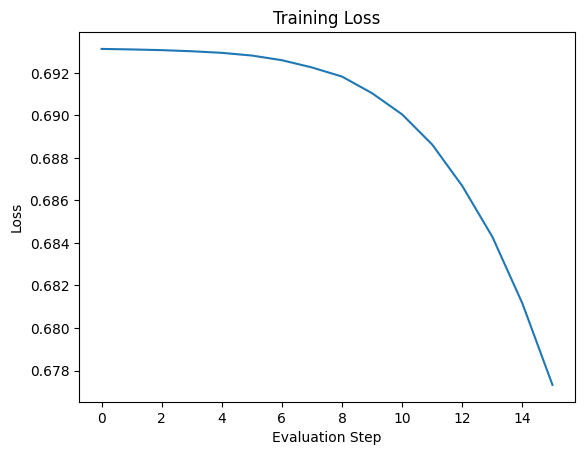

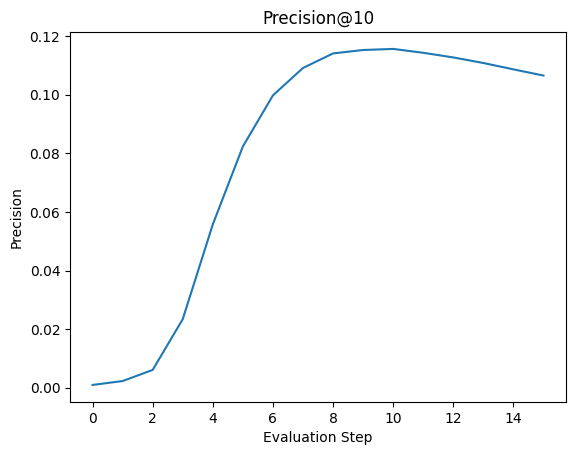

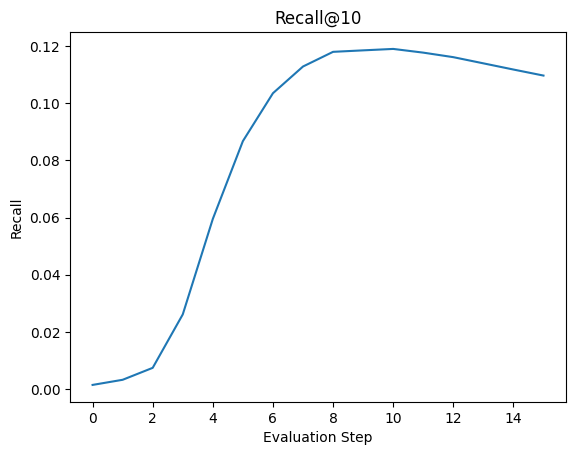

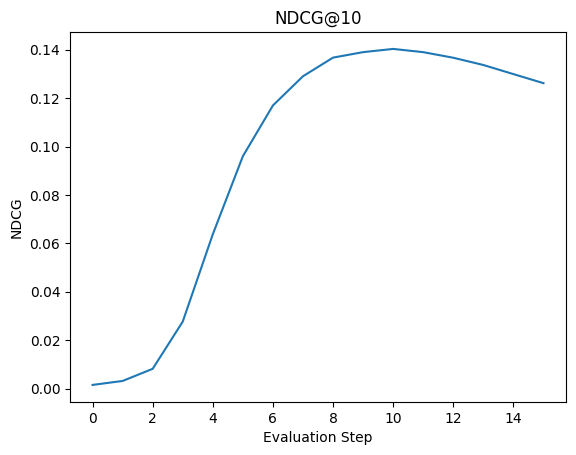

In [ ]:
import matplotlib.pyplot as plt

# Loss
plt.figure()
plt.plot(history["loss"])
plt.title("Training Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.show()

# Precision
plt.figure()
plt.plot(history["precision"])
plt.title("Precision@10")
plt.xlabel("Evaluation Step")
plt.ylabel("Precision")
plt.show()

# Recall
plt.figure()
plt.plot(history["recall"])
plt.title("Recall@10")
plt.xlabel("Evaluation Step")
plt.ylabel("Recall")
plt.show()

# NDCG
plt.figure()
plt.plot(history["ndcg"])
plt.title("NDCG@10")
plt.xlabel("Evaluation Step")
plt.ylabel("NDCG")
plt.show()

In [ ]:
def show_example(model, graph, user_id=0, k=5):
    model.eval()

    with torch.no_grad():
        z, alpha = model()

        user_node = graph["offsets"]["user"] + user_id
        item_emb = z[graph["offsets"]["item"]:
                     graph["offsets"]["item"] + graph["num_items"]]

        scores = item_emb @ z[user_node]

        seen = graph["user_train"][user_id]
        for i in seen:
            scores[i] = -1e9

        topk = torch.topk(scores, k).indices.tolist()

        print("User:", user_id)
        print("Seen items:", list(seen)[:5])
        print("Recommended items:", topk)
        print("Relation weights (alpha):", alpha.tolist())

show_example(model, graph, user_id=0)

User: 0
Seen items: [0, 1, 2, 3, 4]
Recommended items: [238, 241, 237, 249, 106]
Relation weights (alpha): [0.29508525133132935, 0.2335662841796875, 0.23778584599494934, 0.2335626631975174]


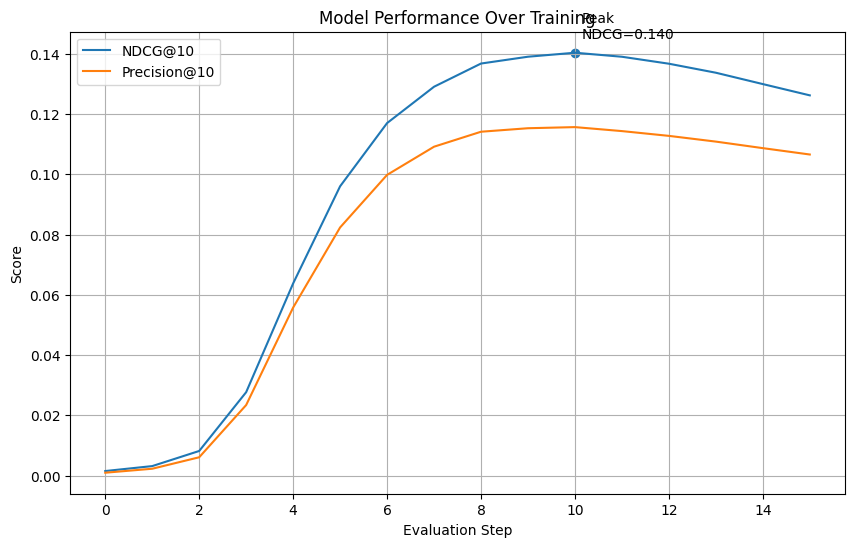

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ndcg = history["ndcg"]
precision = history["precision"]

best_idx = int(np.argmax(ndcg))
best_ndcg = ndcg[best_idx]
best_precision = precision[best_idx]

plt.figure(figsize=(10,6))

plt.plot(ndcg, label="NDCG@10")

plt.plot(precision, label="Precision@10")

plt.scatter(best_idx, best_ndcg)
plt.annotate(f"Peak\nNDCG={best_ndcg:.3f}",
             (best_idx, best_ndcg),
             textcoords="offset points",
             xytext=(5,10))

plt.title("Model Performance Over Training")
plt.xlabel("Evaluation Step")
plt.ylabel("Score")
plt.legend()
plt.grid()

plt.show()

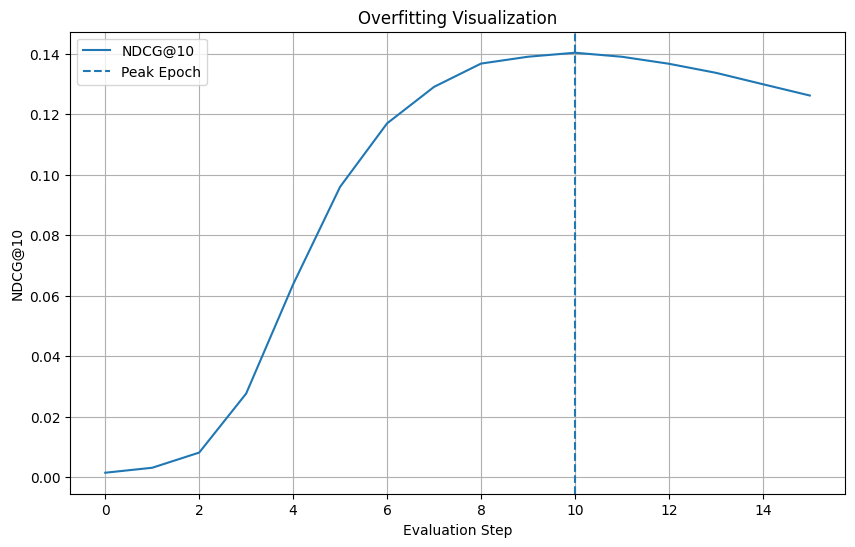

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(ndcg, label="NDCG@10")

plt.axvline(best_idx, linestyle='--', label="Peak Epoch")

plt.title("Overfitting Visualization")
plt.xlabel("Evaluation Step")
plt.ylabel("NDCG@10")
plt.legend()
plt.grid()

plt.show()

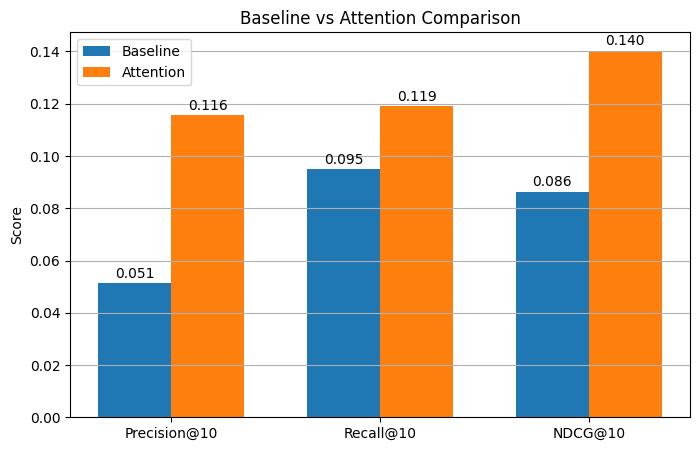

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

baseline = {
    "Precision@10": 0.05148,
    "Recall@10": 0.09513,
    "NDCG@10": 0.08639
}

attention = {
    "Precision@10": max(history["precision"]),
    "Recall@10": max(history["recall"]),
    "NDCG@10": max(history["ndcg"])
}

labels = ["Precision@10", "Recall@10", "NDCG@10"]

baseline_vals = [baseline[k] for k in labels]
attention_vals = [attention[k] for k in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, baseline_vals, width, label="Baseline")
plt.bar(x + width/2, attention_vals, width, label="Attention")

for i, v in enumerate(baseline_vals):
    plt.text(i - width/2, v + 0.002, f"{v:.3f}", ha='center')

for i, v in enumerate(attention_vals):
    plt.text(i + width/2, v + 0.002, f"{v:.3f}", ha='center')

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Baseline vs Attention Comparison")
plt.legend()
plt.grid(axis='y')

plt.show()

In [ ]:
improvement = {
    k: (attention[k] - baseline[k]) / baseline[k] * 100
    for k in baseline
}

print("Improvement (%):")
for k, v in improvement.items():
    print(f"{k}: {v:.1f}%")

Improvement (%):
Precision@10: 124.6%
Recall@10: 25.1%
NDCG@10: 62.4%
